In [1]:
library(ggplot2)
library(Seurat)
library(ggpubr)
library(dplyr)
library(tidyr)
library(rstatix)
library(ComplexHeatmap)
library(circlize)
library(org.At.tair.db)
library(AnnotationDbi)
library(GO.db)
library(readr)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter


Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap p

In [2]:
packageVersion("ggpubr")
packageVersion("org.At.tair.db")

[1] ‘0.6.2’

[1] ‘3.18.0’

Obtain gene lists

In [3]:
go_ids <- c("GO:0009626","GO:0009627","GO:0006096")

all_genes <- keys(org.At.tair.db, keytype = "TAIR")

go_anno_direct <- AnnotationDbi::select(
  org.At.tair.db,
  keys = all_genes,
  keytype = "TAIR",
  columns = c("TAIR", "SYMBOL", "GO", "ONTOLOGY", "EVIDENCE")
)

go_anno_direct_bp <- go_anno_direct[!is.na(go_anno_direct$GO) & go_anno_direct$ONTOLOGY == "BP",]

go_gene_sets_direct <- lapply(go_ids, function(go_id) {
  genes <- unique(go_anno_direct_bp$TAIR[go_anno_direct_bp$GO == go_id])
  genes <- genes[!is.na(genes)]
  genes})

names(go_gene_sets_direct) <- go_ids

sapply(go_gene_sets_direct, length)

'select()' returned 1:many mapping between keys and columns



GO:0009626 GO:0009627 GO:0006096 
        58        104         51

In [4]:
rds <- readRDS("../02.Tomato_callus/data/10x_data/Processed_tomato_10X_CMBinfo.rds")

rds$Clade <- rds$CMB_info

rds$Clade <- gsub("Vascular_tissue_cmb_0", "Clade_inn1", rds$Clade)
rds$Clade <- gsub("Inner_callus_cmb_1", "Clade_inn1", rds$Clade)

rds$Clade <- gsub("Vascular_tissue_cmb_1", "Clade_inn2", rds$Clade)
rds$Clade <- gsub("Inner_callus_cmb_3", "Clade_inn2", rds$Clade)
rds$Clade <- gsub("Inner_callus_cmb_0", "Clade_inn2", rds$Clade)
rds$Clade <- gsub("Inner_callus_cmb_2", "Clade_inn2", rds$Clade)
rds$Clade <- gsub("Vascular_tissue_cmb_2", "Clade_inn2", rds$Clade)
rds$Clade <- gsub("Vascular_tissue_cmb_3", "Clade_inn2", rds$Clade)
rds <- subset(rds, Clade %in% c("Clade_inn1","Clade_inn2"))
rds <- subset(rds, annotation %in% c("Inner_callus"))

rds@images <- lapply(rds@images, UpdateSlots) 

table(rds$Clade)
table(rds$CMB_info)


Clade_inn1 Clade_inn2 
       239        434 


Inner_callus_cmb_0 Inner_callus_cmb_1 Inner_callus_cmb_2 Inner_callus_cmb_3 
               205                239                134                 95 

In [5]:
ortho <- read.csv("00.Data_Backup/Tomato_to_Arabidopsis.csv", stringsAsFactors = FALSE, check.names = FALSE)
ortho <- ortho %>% mutate(Tomato_gene = Tomato_query, Arabidopsis_Gene = toupper(Arabidopsis_Gene))
tomato_features <- rownames(rds)
length(unique(ortho$Tomato_gene))
length(unique(tomato_features))

[1] 18319

[1] 18103

In [6]:
go_gene_sets_tomato <- lapply(names(go_gene_sets_direct), function(go_id) {
  ath_genes <- go_gene_sets_direct[[go_id]]

  tomato_genes <- ortho %>%
    filter(Arabidopsis_Gene %in% ath_genes) %>%
    pull(Tomato_gene) %>%
    unique()

  tomato_genes <- tomato_genes[!is.na(tomato_genes)]
  tomato_genes <- intersect(tomato_genes, tomato_features)

  tomato_genes
})

names(go_gene_sets_tomato) <- names(go_gene_sets_direct)

go_mapping_summary <- data.frame(
  GO_ID = names(go_gene_sets_direct),
  n_Arabidopsis_genes = sapply(go_gene_sets_direct, length),
  n_Tomato_genes_matched = sapply(go_gene_sets_tomato, length),
  stringsAsFactors = FALSE
)

go_mapping_summary

min_genes <- 5

go_gene_sets_tomato_use <- go_gene_sets_tomato[
  sapply(go_gene_sets_tomato, length) >= min_genes
]

sapply(go_gene_sets_tomato_use, length)

,GO_ID,n_Arabidopsis_genes,n_Tomato_genes_matched
,<chr>,<int>,<int>
GO:0009626,GO:0009626,58,101
GO:0009627,GO:0009627,104,157
GO:0006096,GO:0006096,51,49


GO:0009626 GO:0009627 GO:0006096 
       101        157         49

In [7]:
rds <- AddModuleScore(object = rds, features = go_gene_sets_tomato_use, assay = "SCT", name = "Tomato_GO_score", seed = 1)

In [8]:
old_cols <- paste0("Tomato_GO_score", seq_along(go_gene_sets_tomato_use))
new_cols <- paste0(gsub(":", "_", names(go_gene_sets_tomato_use)), "_score")

colnames(rds@meta.data)[match(old_cols, colnames(rds@meta.data))] <- new_cols
new_cols

[1] "GO_0009626_score" "GO_0009627_score" "GO_0006096_score"

The default behaviour of split.by has changed.
Separate violin plots are now plotted side-by-side.
To restore the old behaviour of a single split violin,
set split.plot = TRUE.
      
This message will be shown once per session.

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
“The `fun.y` argument of `stat_summary()` is de

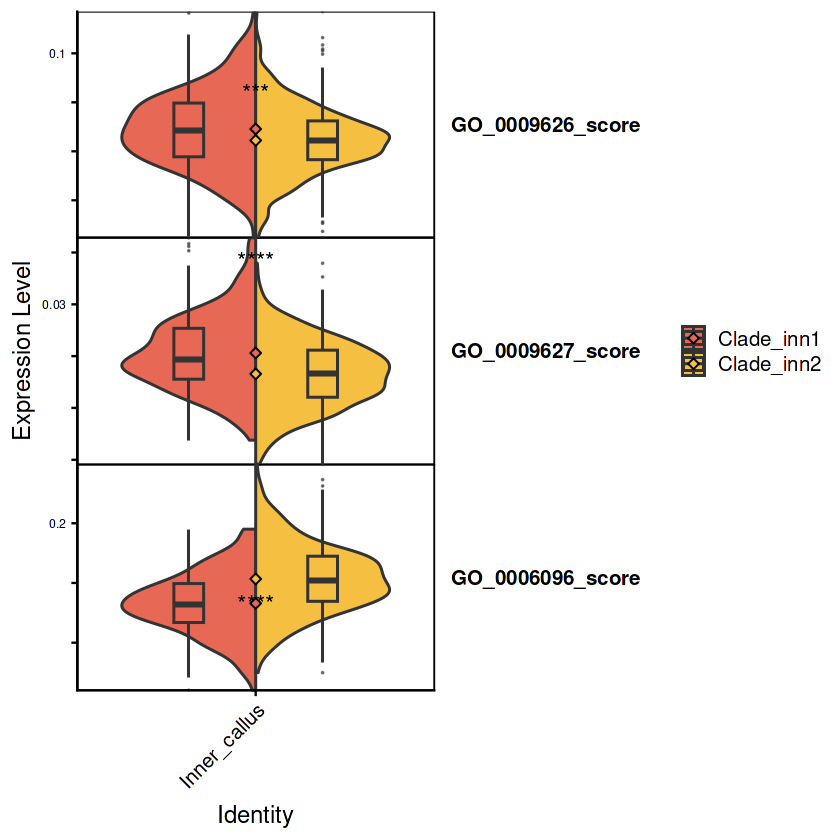

In [9]:
#pdf("Addmodulescore_InnerOnly_Clade_inn1_inn2_new.pdf",5,4)
VlnPlot(rds, features = new_cols, pt.size = 0.1, group.by = "annotation", stack = T, flip = T, split.by = "Clade", split.plot = TRUE) +
    scale_fill_manual(values = c("#e86856","#f5bf42")) +
    stat_compare_means(method='wilcox.test', label='p.signif', label.y=0.05) +
    geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), alpha = 0.6, outlier.size = 0) +
    stat_summary(fun.y=mean, geom="point", shape=23, size=2)
#dev.off()

Permutation of inner callus Clade #1 and Clade #2 labels using 1,000 random seeds

In [21]:
library(dplyr)
library(tidyr)
library(purrr)
library(tibble)

score_cols <- c("GO_0009626_score", "GO_0009627_score", "GO_0006096_score")
target_clades <- c("Clade_inn1", "Clade_inn2")

meta_df <- rds@meta.data %>%
  tibble::rownames_to_column("cell") %>%
  dplyr::filter(Clade %in% target_clades) %>%
  dplyr::mutate(
    Clade = factor(Clade, levels = target_clades)
  )

table(meta_df$Clade)

run_score_tests <- function(df, group_col = "Clade", score_cols_use, comparison_name = "real") {
  
  res <- purrr::map_dfr(score_cols_use, function(score) {
    
    tmp <- df %>%
      dplyr::select(dplyr::all_of(group_col), dplyr::all_of(score)) %>%
      dplyr::rename(
        group = dplyr::all_of(group_col),
        score_value = dplyr::all_of(score)
      ) %>%
      dplyr::filter(!is.na(group), !is.na(score_value))
    
    group1 <- target_clades[1]
    group2 <- target_clades[2]
    
    x1 <- tmp$score_value[tmp$group == group1]
    x2 <- tmp$score_value[tmp$group == group2]
    
    wt <- wilcox.test(x1, x2, alternative = "two.sided", exact = FALSE)
    
    tibble::tibble(
      comparison = comparison_name,
      score = score,
      n_Clade_inn1 = length(x1),
      n_Clade_inn2 = length(x2),
      mean_Clade_inn1 = mean(x1, na.rm = TRUE),
      mean_Clade_inn2 = mean(x2, na.rm = TRUE),
      median_Clade_inn1 = median(x1, na.rm = TRUE),
      median_Clade_inn2 = median(x2, na.rm = TRUE),
      delta_mean_inn2_minus_inn1 = mean(x2, na.rm = TRUE) - mean(x1, na.rm = TRUE),
      p_value = wt$p.value
    )
  }) %>%
    dplyr::mutate(
      p_adj_BH = p.adjust(p_value, method = "BH") # BH test on 3 scores
    )
  
  return(res)
}

real_res <- run_score_tests(
  df = meta_df,
  group_col = "Clade",
  score_cols_use = score_cols,
  comparison_name = "real_label"
)

real_res


Clade_inn1 Clade_inn2 
       239        434 

comparison,score,n_Clade_inn1,n_Clade_inn2,mean_Clade_inn1,mean_Clade_inn2,median_Clade_inn1,median_Clade_inn2,delta_mean_inn2_minus_inn1,p_value,p_adj_BH
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
real_label,GO_0009626_score,239,434,0.022773463,0.01111414,0.020872785,0.01102531,-0.01165932,2.261055e-04,2.261055e-04
real_label,GO_0009627_score,239,434,0.001804422,-0.01028778,-0.001712282,-0.01006401,-0.01209220,4.752443e-11,7.128665e-11
real_label,GO_0006096_score,239,434,0.065816824,0.10675085,0.064666537,0.10441987,0.04093402,5.244225e-18,1.573268e-17


In [22]:
set.seed(123)

perm_res <- purrr::map_dfr(1:1000, function(seed_i) {
  
  set.seed(seed_i)
  
  perm_df <- meta_df %>%
    dplyr::mutate(
      Clade_permuted = sample(Clade, size = dplyr::n(), replace = FALSE), Clade_permuted = factor(Clade_permuted, levels = target_clades)
    )
  
  run_score_tests(
    df = perm_df,
    group_col = "Clade_permuted",
    score_cols_use = score_cols,
    comparison_name = paste0("permuted_seed_", seed_i)
  ) %>%
    dplyr::mutate(seed = seed_i)
})

all_res <- dplyr::bind_rows(
  real_res %>% dplyr::mutate(seed = NA_integer_),
  perm_res
)

all_res

write.csv(
  all_res,
  "Tomato_inn_Clades_Permutation/Clade_inn1_vs_inn2_GO_score_real_and_permuted_tests.csv",
  row.names = FALSE
)

empirical_perm_p <- purrr::map_dfr(score_cols, function(score_i) {
  
  real_delta_i <- real_res %>%
    dplyr::filter(score == score_i) %>%
    dplyr::pull(delta_mean_inn2_minus_inn1)
  
  perm_delta_i <- perm_res %>%
    dplyr::filter(score == score_i) %>%
    dplyr::pull(delta_mean_inn2_minus_inn1)
  
  n_perm <- length(perm_delta_i)
  n_more_extreme <- sum(abs(perm_delta_i) >= abs(real_delta_i))
  
  tibble::tibble(
    score = score_i,
    real_delta_mean_inn2_minus_inn1 = real_delta_i,
    n_perm = n_perm,
    n_perm_more_extreme = n_more_extreme,
    empirical_p_two_sided = (1 + n_more_extreme) / (1 + n_perm),
    perm_mean_abs_delta = mean(abs(perm_delta_i), na.rm = TRUE),
    perm_max_abs_delta = max(abs(perm_delta_i), na.rm = TRUE)
  )
})

empirical_perm_p # empirical_p_two_sided is used for permutation test

write.csv(
  empirical_perm_p,
  "Tomato_inn_Clades_Permutation/Clade_inn1_vs_inn2_GO_score_empirical_permutation_p.csv",
  row.names = FALSE
)

comparison,score,n_Clade_inn1,n_Clade_inn2,mean_Clade_inn1,mean_Clade_inn2,median_Clade_inn1,median_Clade_inn2,delta_mean_inn2_minus_inn1,p_value,p_adj_BH,seed
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
real_label,GO_0009626_score,239,434,0.022773463,0.011114141,0.020872785,0.011025305,-1.165932e-02,2.261055e-04,2.261055e-04,NA
real_label,GO_0009627_score,239,434,0.001804422,-0.010287776,-0.001712282,-0.010064007,-1.209220e-02,4.752443e-11,7.128665e-11,NA
real_label,GO_0006096_score,239,434,0.065816824,0.106750848,0.064666537,0.104419873,4.093402e-02,5.244225e-18,1.573268e-17,NA
permuted_seed_1,GO_0009626_score,239,434,0.013897156,0.016002245,0.013703288,0.014669749,2.105090e-03,6.043994e-01,6.043994e-01,1
permuted_seed_1,GO_0009627_score,239,434,-0.007752395,-0.005024920,-0.006462548,-0.006088542,2.727475e-03,2.348293e-01,6.043994e-01,1
permuted_seed_1,GO_0006096_score,239,434,0.093811996,0.091334152,0.096072948,0.086505681,-2.477844e-03,4.330013e-01,6.043994e-01,1
permuted_seed_2,GO_0009626_score,239,434,0.015274858,0.015243557,0.013778638,0.015036229,-3.130057e-05,6.609960e-01,6.609960e-01,2
permuted_seed_2,GO_0009627_score,239,434,-0.005288525,-0.006381752,-0.005668423,-0.006850968,-1.093227e-03,5.603638e-01,6.609960e-01,2
permuted_seed_2,GO_0006096_score,239,434,0.097180118,0.089479357,0.093988822,0.088521456,-7.700761e-03,1.704630e-01,5.113890e-01,2


score,real_delta_mean_inn2_minus_inn1,n_perm,n_perm_more_extreme,empirical_p_two_sided,perm_mean_abs_delta,perm_max_abs_delta
<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
GO_0009626_score,-0.01165932,1000,0,0.000999001,0.002404921,0.010059950
GO_0009627_score,-0.01209220,1000,0,0.000999001,0.001391760,0.005250158
GO_0006096_score,0.04093402,1000,0,0.000999001,0.003683280,0.014731322


In [23]:
perm_summary <- perm_res %>%
  dplyr::mutate(
    significant = p_adj_BH < 0.05,
    direction = dplyr::case_when(
      delta_mean_inn2_minus_inn1 > 0 ~ "Clade_inn2_higher",
      delta_mean_inn2_minus_inn1 < 0 ~ "Clade_inn1_higher",
      TRUE ~ "no_difference"
    )
  ) %>%
  dplyr::group_by(score) %>%
  dplyr::summarise(
    n_permutations = dplyr::n(),
    n_significant = sum(significant),
    significant_rate = n_significant / n_permutations,
    n_inn1_higher = sum(direction == "Clade_inn1_higher"),
    n_inn2_higher = sum(direction == "Clade_inn2_higher"),
    mean_abs_delta = mean(abs(delta_mean_inn2_minus_inn1), na.rm = TRUE),
    .groups = "drop"
  )

perm_summary

write.csv(
  perm_summary,
  "Tomato_inn_Clades_Permutation/Clade_inn1_vs_inn2_GO_score_permutation_summary.csv",
  row.names = FALSE
)

score,n_permutations,n_significant,significant_rate,n_inn1_higher,n_inn2_higher,mean_abs_delta
<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
GO_0006096_score,1000,14,0.014,493,507,0.003683280
GO_0009626_score,1000,20,0.020,515,485,0.002404921
GO_0009627_score,1000,23,0.023,505,495,0.001391760


In [24]:
library(dplyr)
library(ggplot2)

score_labels <- c(
  "GO_0006096_score" = "GO:0006096\nGlycolytic process",
  "GO_0009626_score" = "GO:0009626\nDefense/stress response",
  "GO_0009627_score" = "GO:0009627\nDefense response"
)

perm_plot_df <- perm_res %>%
  dplyr::mutate(
    score_label = dplyr::recode(score, !!!score_labels)
  )

real_plot_df <- real_res %>%
  dplyr::mutate(
    score_label = dplyr::recode(score, !!!score_labels)
  )

p_perm <- ggplot(
  perm_plot_df,
  aes(x = delta_mean_inn2_minus_inn1)
) +
  geom_histogram(
    bins = 50,
    fill = "grey80",
    color = "white"
  ) +
  geom_vline(
    data = real_plot_df,
    aes(xintercept = delta_mean_inn2_minus_inn1),
    color = "red",
    linewidth = 1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed",
    linewidth = 0.4
  ) +
  facet_wrap(~score_label, scales = "free") +
  theme_classic(base_size = 12) +
  labs(
    x = "Mean score difference: Clade_inn2 - Clade_inn1",
    y = "Number of permutations"
  )

pdf("Tomato_inn_Clades_Permutation/Clade_inn1_vs_inn2_GO_score_permutation_delta_distribution.pdf", width = 8, height = 3.2)
print(p_perm)
dev.off()

perm_summary_plot <- perm_summary %>%
  dplyr::mutate(
    score_label = dplyr::recode(score, !!!score_labels),
    significant_rate_percent = significant_rate * 100
  )

p_sig_rate <- ggplot(
  perm_summary_plot,
  aes(x = score_label, y = significant_rate_percent)
) +
  geom_col(width = 0.65) +
  geom_hline(
    yintercept = 5,
    linetype = "dashed",
    linewidth = 0.4
  ) +
  theme_classic(base_size = 12) +
  labs(
    x = NULL,
    y = "Significant randomized comparisons (%)"
  ) +
  theme(
    axis.text.x = element_text(angle = 35, hjust = 1)
  )

pdf("Tomato_inn_Clades_Permutation/Clade_inn1_vs_inn2_GO_score_permutation_significant_rate.pdf", width = 5, height = 3.5)
print(p_sig_rate)
dev.off()

agg_record_1085875422 
                    2

agg_record_1085875422 
                    2